### **Random Forest: Predicting Wine Quality**

#### Objective:
Your task is to build a **Random Forest** model to predict the quality of wine based on its physicochemical properties. This homework will help you understand how Random Forest works for regression tasks and evaluate its performance.

---

#### Dataset:
Use the **Wine Quality dataset** from the UCI Machine Learning Repository. It contains information on the physicochemical properties of wine and a target variable for wine quality, rated on a scale of 0 to 10.

You can download it from [Wine Quality Dataset](https://archive.ics.uci.edu/ml/datasets/Wine+Quality). Alternatively, it's also available on [Kaggle](https://www.kaggle.com/uciml/red-wine-quality-cortez-et-al-2009).

---

#### Dataset Overview:
Key features:
- **Fixed acidity**
- **Volatile acidity**
- **Citric acid**
- **Residual sugar**
- **Chlorides**
- **Free sulfur dioxide**
- **Total sulfur dioxide**
- **Density**
- **pH**
- **Sulphates**
- **Alcohol**

Target variable:
- **Quality**: Integer value (0–10) representing wine quality.

---

#### Steps to Complete:

1. **Data Loading and Exploration**
   - Load the dataset using `pandas`.
   - Display the first few rows to understand the data structure.
   - Check for missing values and handle them if necessary.
   - Explore the distribution of each feature using histograms.
   - Analyze the correlation between features and the target variable.

2. **Data Preprocessing**
   - Standardize the features using `StandardScaler` or `MinMaxScaler`.
   - Split the data into training (80%) and test (20%) sets using `train_test_split`.

3. **Train a Random Forest Regressor**
   - Train a Random Forest model using `RandomForestRegressor` from `sklearn.ensemble`.
   - Use the default hyperparameters initially.
   - Evaluate the model on the test set using:
     - **Mean Absolute Error (MAE)**.
     - **Mean Squared Error (MSE)**.
     - **R-squared score**.

4. **Feature Importance**
   - Extract feature importance from the trained model.
   - Plot the feature importance using a bar chart.
   - Identify which features are most significant for predicting wine quality.

5. **Hyperparameter Tuning**
   - Use `GridSearchCV` or `RandomizedSearchCV` to optimize key hyperparameters:
     - `n_estimators` (number of trees).
     - `max_depth` (maximum depth of the trees).
     - `min_samples_split` and `min_samples_leaf`.
     - `max_features`.
   - Compare the performance of the tuned model to the default model.

6. **Insights**
   - Analyze how well the model predicts wine quality.
   - Discuss any challenges in predicting this target variable (e.g., subjective nature of wine quality ratings, potential overfitting, etc.).

---

#### Bonus Challenges (Optional):

1. **Classification Task**
   - Convert the problem into a classification task by grouping the wine quality ratings into categories (e.g., `Low`, `Medium`, `High`).
   - Train a `RandomForestClassifier` instead of a regressor and evaluate the model using classification metrics (e.g., accuracy, precision, recall).

2. **Comparison with Other Models**
   - Compare the Random Forest's performance with:
     - **Linear Regression** for regression.
     - **Logistic Regression** for classification.

3. **Real-World Interpretation**
   - Discuss how the most important features (e.g., alcohol, acidity) affect wine quality in practical terms.

4. **Advanced Visualization**
   - Use **Partial Dependence Plots (PDP)** or **SHAP** to visualize the relationship between features and predictions.

---

#### Deliverables:
- A Python script or Jupyter Notebook containing:
  - Code for loading, exploring, and preprocessing the dataset.
  - Implementation of Random Forest with evaluation metrics.
  - Plots for feature importance and evaluation results.
- A brief report discussing:
  - The key insights from the dataset.
  - The importance of various features.
  - The impact of hyperparameter tuning on model performance.

---

#### Useful Hints:
- Use `seaborn` and `matplotlib` for visualizations.
- For hyperparameter tuning, set `n_jobs=-1` to utilize all CPU cores.
- Random Forest works well without scaling, but scaling can improve interpretability.

---

### Key Learning Goals:
- Understand how Random Forest handles regression tasks.
- Learn the importance of hyperparameter tuning.
- Gain insights into feature importance and how it aids interpretability.
- Experience the flexibility of Random Forest for both regression and classification.

In [1]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


In [2]:
# Load dataset (red wine example)
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-red.csv"
df = pd.read_csv(url, sep=';')

# Preview dataset
print(df.shape)
df.head()


(1599, 12)


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
dtype: int64


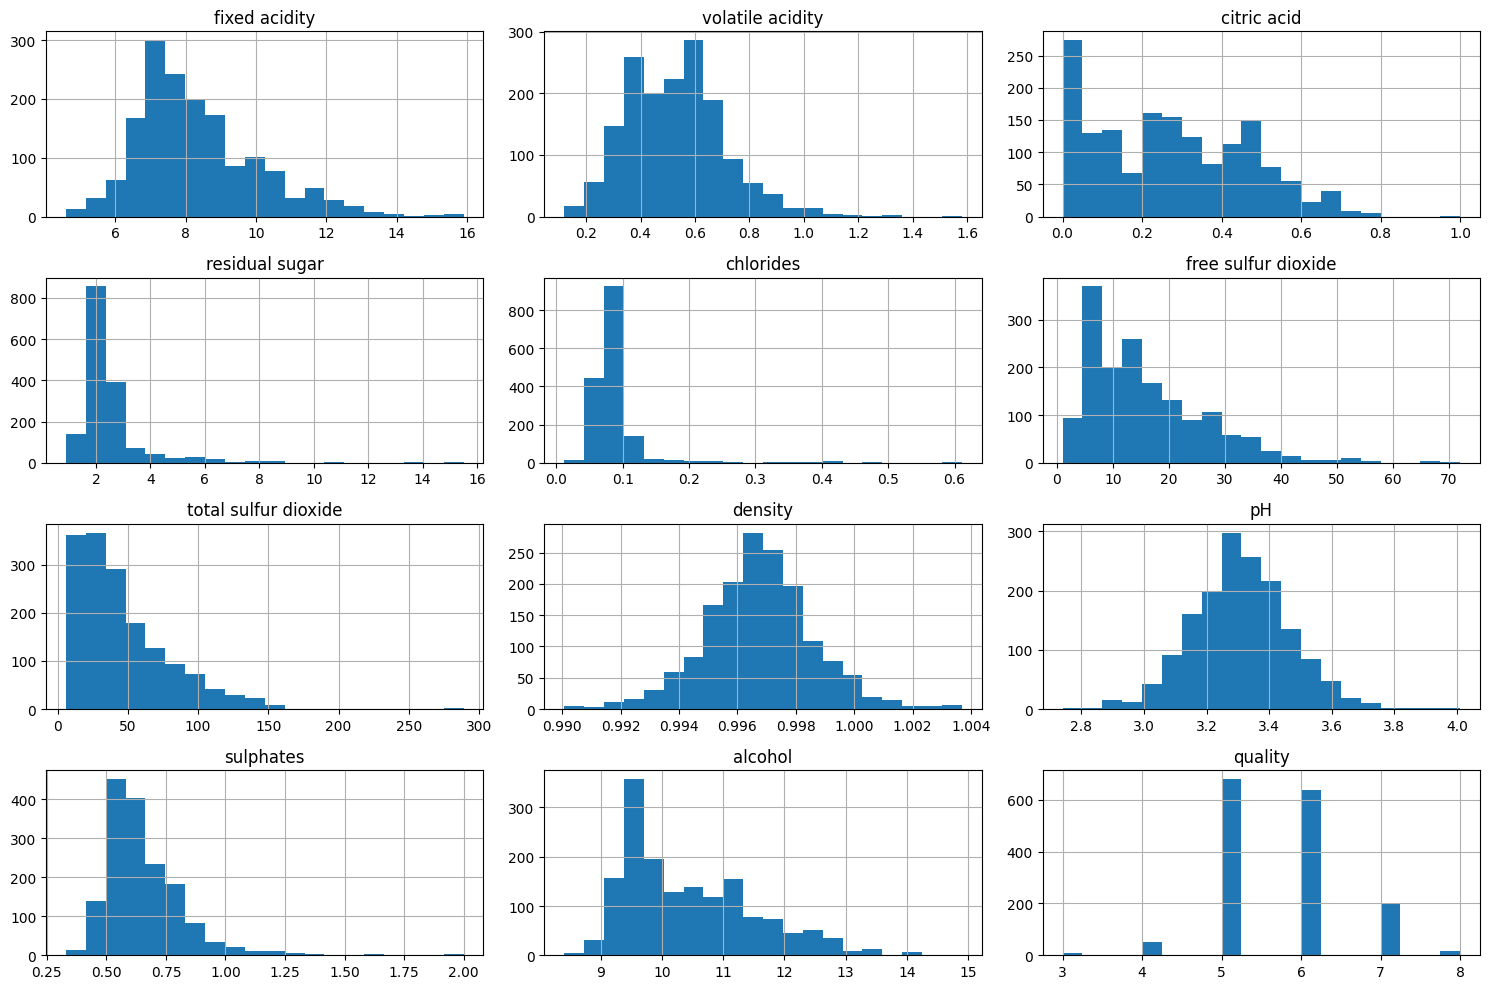

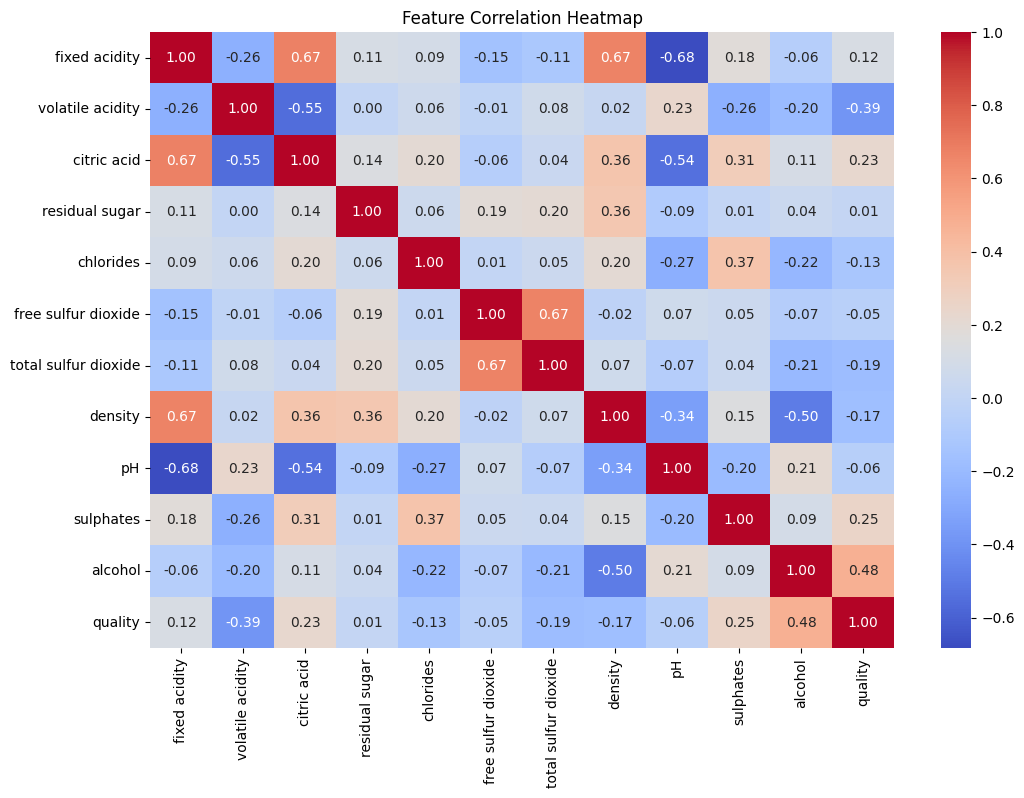

In [3]:
# Check for missing values
print(df.isnull().sum())

# Explore distribution of features
df.hist(bins=20, figsize=(15, 10))
plt.tight_layout()
plt.show()

# Correlation heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Feature Correlation Heatmap")
plt.show()


In [4]:
# Features & target
X = df.drop("quality", axis=1)
y = df["quality"]

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scaling features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [6]:
# Train default Random Forest
rf = RandomForestRegressor(random_state=42)
rf.fit(X_train_scaled, y_train)

# Predictions
y_pred = rf.predict(X_test_scaled)

# Evaluation
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Random Forest - Default Parameters")
print("MAE:", mae)
print("MSE:", mse)
print("R2:", r2)


Random Forest - Default Parameters
MAE: 0.4219687499999999
MSE: 0.3006603124999999
R2: 0.5399271357910311


C:\Users\Mezon\AppData\Local\Temp\ipykernel_10376\1988635240.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances, y=features, palette="viridis")


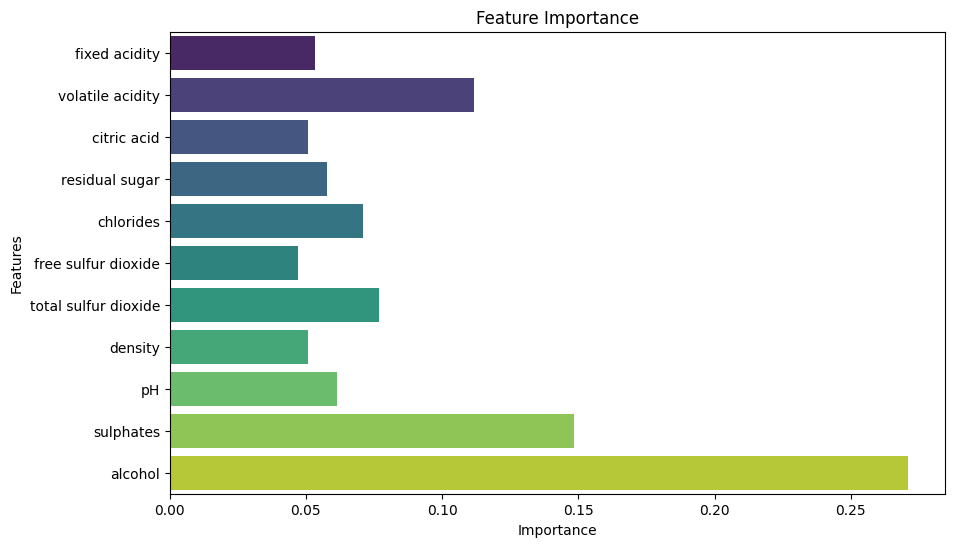

In [7]:
# Feature importance
importances = rf.feature_importances_
features = X.columns

# Plot
plt.figure(figsize=(10, 6))
sns.barplot(x=importances, y=features, palette="viridis")
plt.title("Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Features")
plt.show()


In [8]:
# Define parameter grid for RandomizedSearchCV
param_grid = {
    "n_estimators": [100, 200, 300, 500],
    "max_depth": [None, 5, 10, 20],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["auto", "sqrt", "log2"]
}

# Randomized search
rf_random = RandomizedSearchCV(
    estimator=RandomForestRegressor(random_state=42),
    param_distributions=param_grid,
    n_iter=20,
    scoring="r2",
    cv=3,
    verbose=2,
    random_state=42,
    n_jobs=-1
)

rf_random.fit(X_train_scaled, y_train)
print("Best parameters:", rf_random.best_params_)

# Evaluate tuned model
best_model = rf_random.best_estimator_
y_pred_tuned = best_model.predict(X_test_scaled)

print("Tuned Random Forest")
print("MAE:", mean_absolute_error(y_test, y_pred_tuned))
print("MSE:", mean_squared_error(y_test, y_pred_tuned))
print("R²:", r2_score(y_test, y_pred_tuned))


Fitting 3 folds for each of 20 candidates, totalling 60 fits


c:\Users\Mezon\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\model_selection\_validation.py:528: FitFailedWarning: 
9 fits failed out of a total of 60.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
3 fits failed with the following error:
Traceback (most recent call last):
  File "c:\Users\Mezon\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\model_selection\_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "c:\Users\Mezon\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\base.py", line 1382, in wrapper
    estimator._validate_params()
  File "c:\Users\Mezon\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\base.py",

Best parameters: {'n_estimators': 500, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 'log2', 'max_depth': None}
Tuned Random Forest
MAE: 0.41440625000000003
MSE: 0.2924527125
R²: 0.5524864723023357
